# 🌊 Wave Buoy Data from the U.S. National Data Buoy Center (NDBC)

> **Inputs:**
>
> **Outputs:**
> - Folder per buoy ID:
>   - `raw_data.csv`: downloaded data in the folder `inputs/buoy_data/buoy_ID`
>   - `buoy_buoy_ID_bulk_parameters.pkl`: wave bulk parameters (Hs, Tp, Dp) stored in the `inputs/buoy_data/` folder.
>
> `.pkl` files are used to validate CAWCR spectra satellite correction and BinWaves results
>
> **NOTE:** Directionl spectra can be also downloaded from NDBC, although isn´t needed for the BinWaves


---

#### Before You Start

Make sure you have:

- Installed the latest version of `bluemath-tk`:  
  ```bash
  pip install bluemath-tk

- **BlueMath Toolkit Repository**:  [https://github.com/GeoOcean/BlueMath_tk.git](https://github.com/GeoOcean/BlueMath_tk.git)

Before continuing, ensure you have **created and activated a Python environment**.

---

Wave bulk parameters is retrieved from the **National Data Buoy Center (NDBC)**:  
🔗 [https://www.ndbc.noaa.gov/](https://www.ndbc.noaa.gov/)

This notebook downloads and visualizes historical wave buoy data, including:

- **Bulk wave parameters**
- **Density energy spectra** (when available)
- **Directional wave spectra** (when available)

📘 **Reference documentation:**
- [NDBC Web Data Guide](https://www.ndbc.noaa.gov/docs/ndbc_web_data_guide.pdf)  
- [Measurement Descriptions & Units](https://www.ndbc.noaa.gov/faq/measdes.shtml)


---


<summary><strong>📥 Downloading Bulk Wave Parameters</strong></summary>

This section downloads time series data (e.g., significant wave height, period, direction) for a given buoy.

- NDBC data files are organized by year.
- File formats and available variables vary across years.
- This script handles inconsistencies and outputs a clean, standardized dataset.

---


<summary><strong>🌊 Downloading Density Energy Spectra</strong></summary>

This section retrieves **density energy spectra** data, stored in yearly files.

- Formats vary (e.g., frequency resolution, date formatting).
- The script processes each year independently but allows plotting across multiple years.
- Only buoys with a `"w"` suffix provide wave spectra. If data is unavailable, an HTTP 404 is raised and skipped.

📘 **More info:** [Wave Spectra Description](https://www.ndbc.noaa.gov/faq/wavespectra.shtml)



---


<summary><strong>🧭 Directional Wave Spectrum Reconstruction</strong></summary>

To reconstruct the directional wave spectrum, multiple coefficient files must be downloaded.

The directional spectrum is:

\[
\begin{align*}
S(f, A) = C_{11}(f) \cdot D(f, A)
\end{align*}
\]

Where:

- \( f \) = frequency (Hz)  
- \( A \) = azimuth angle (°), measured clockwise from true North (direction **waves come from**)  
- \( D(f, A) \) is defined as:

\[
\begin{align*}
D(f, A) = \frac{1}{\pi} \left[ 0.5 + R_1 \cos(A - \alpha_1) + R_2 \cos\left(2(A - \alpha_2)\right) \right]
\end{align*}
\]

### Fourier Coefficients

\[
\begin{align*}
R_1 &= \frac{\sqrt{a_1^2 + b_1^2}}{a_0} \\
R_2 &= \frac{\sqrt{a_2^2 + b_2^2}}{a_0} \\
\alpha_1 &= 270^\circ - \arctan2(b_1, a_1) \\
\alpha_2 &= 270^\circ - 0.5 \cdot \arctan2(b_2, a_2) \pm 180^\circ
\end{align*}
\]

### Notes

- Historical monthly/yearly `R1` and `R2` values are scaled by 100 → multiply by **0.01**
- \( D(f, A) \) may contain **negative values** due to cosine terms.
  - See: *Earle et al., Ocean Engineering (1999)* for methods to handle this
- \( \alpha_2 \) may be adjusted by 180° to minimize its difference with \( \alpha_1 \)

📘 **Further Reading:**  
Earle, Steele & Wang (1999). *Use of advanced directional wave spectra analysis methods*. Ocean Engineering, 26(12), 1421–1434.




In [1]:
from bluemath_tk.downloaders.noaa.noaa_downloader import NOAADownloader
noaa_downloader = NOAADownloader(base_path_to_download="inputs")
noaa_downloader

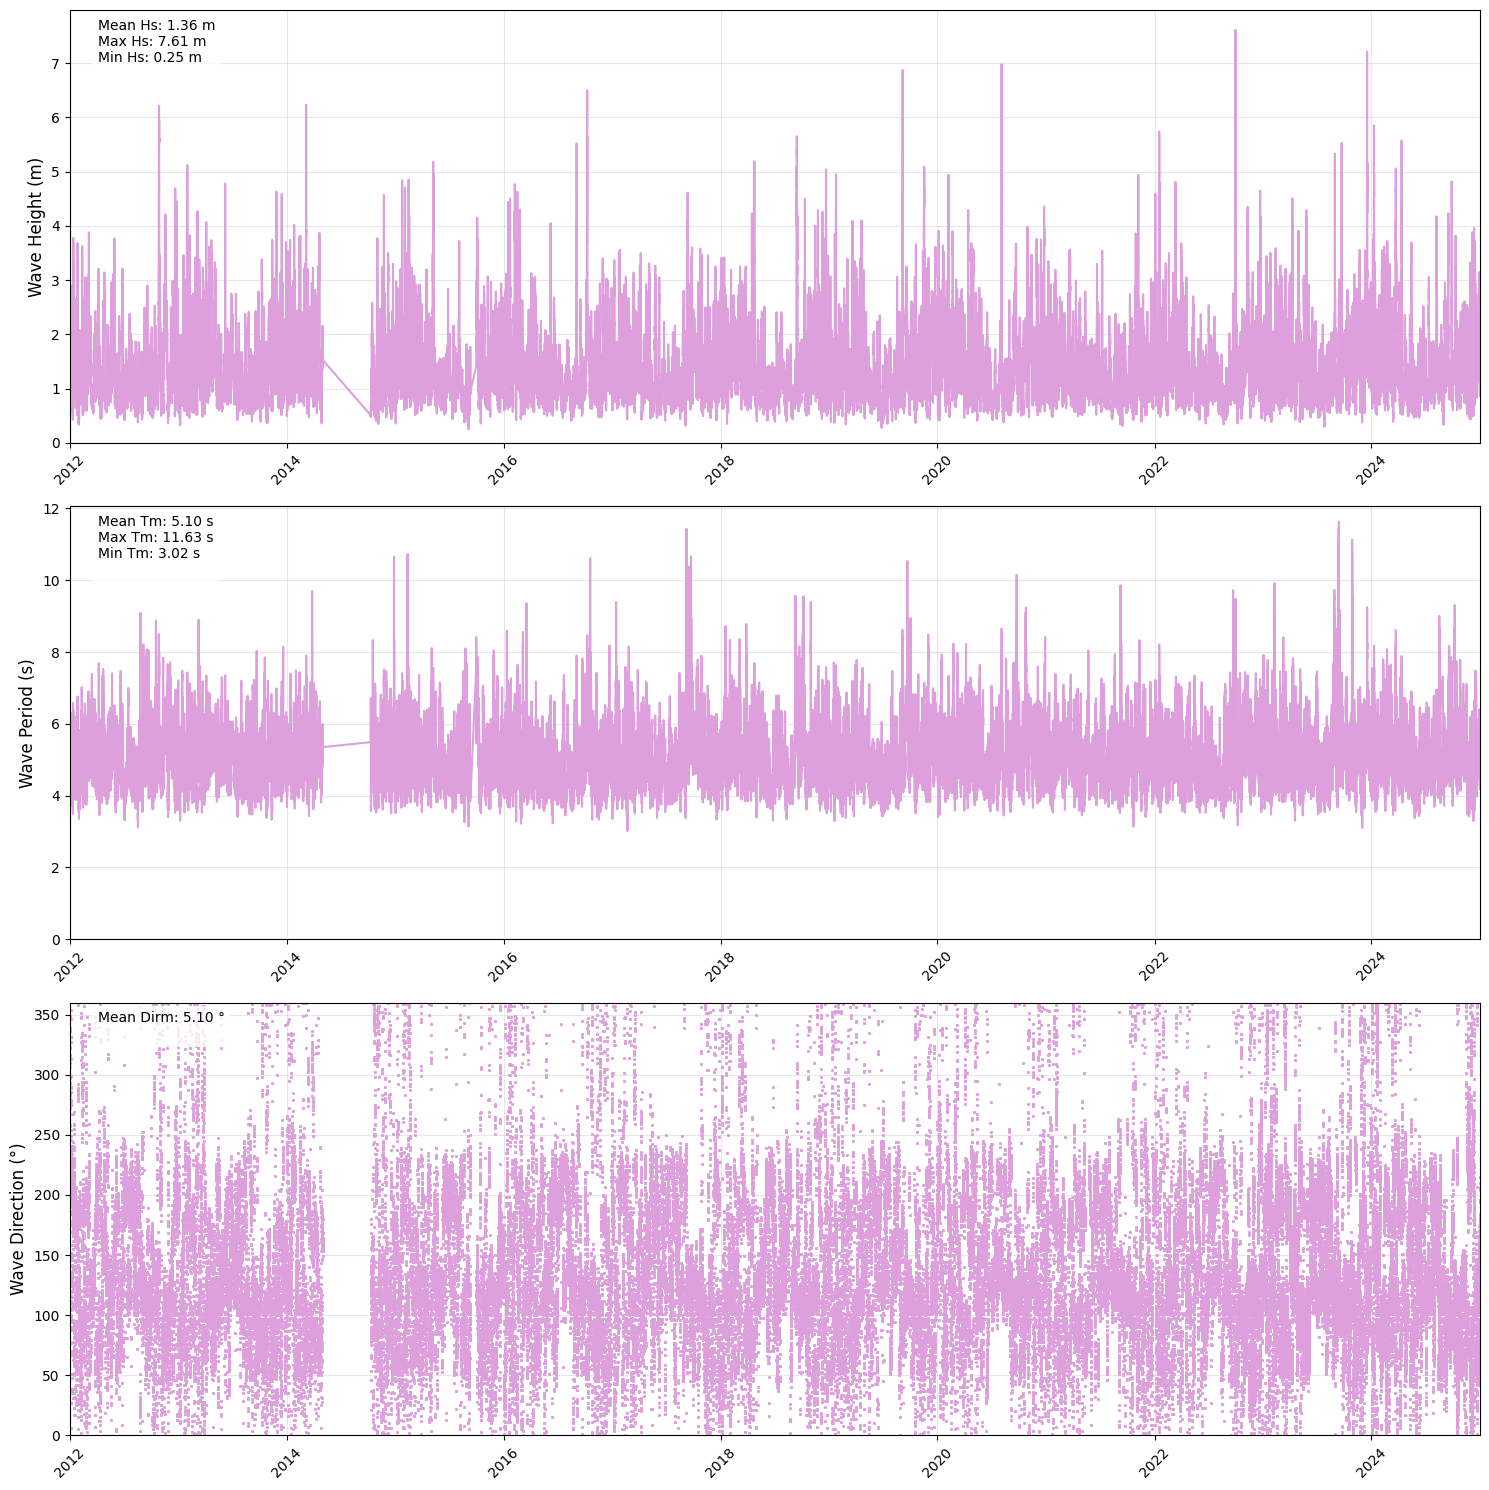

In [2]:
from utils.NDBC_utils import plot_bulk_timeseries
# buoy_ids = ['41013','41025','41108','41110','41120','41159','44056','44086','44088','44095','44100']
buoy_ids = ['41013']

for buoy_id in buoy_ids:
    buoy_df = noaa_downloader.download_data(
        data_type="bulk_parameters",
        load_df=True,
        buoy_id=buoy_id,
        years= list(range(2012, 2025)) ,
    )
    _fig = plot_bulk_timeseries(buoy_df)

In [3]:
from utils.NDBC_utils import convert_buoy_csv_to_pkl

for buoy_id in buoy_ids:
    csv_path = f'./inputs/buoy_data/{buoy_id}/buoy_{buoy_id}_bulk_parameters.csv'
    output_pkl_path = f'./inputs/buoy_data/buoy_{buoy_id}_bulk_parameters.pkl'
    convert_buoy_csv_to_pkl(csv_path, output_pkl_path)

/vols/abedul/home/grupos/geocean/montanoj/BlueMath/climate_services/hindcast/NorthCarolina/utils/NDBC_utils.py:62: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample('1H').agg({



Successfully converted ./inputs/buoy_data/41013/buoy_41013_bulk_parameters.csv to ./inputs/buoy_data/buoy_41013_bulk_parameters.pkl


## Directional Wave Spectrum

> ⚠️ **NO NEEDED FOR BINWAVES**  

### Download directional buoy spectra from NCDB 

In [4]:
# Download directional spectra from NOAA for a specific buoy and time period. 
direc_df_41013 = noaa_downloader.download_data(
    data_type="directional_spectra",
    load_df=True,
    buoy_id="41013",
    years=[2023],
)
direc_df_41013

(                     0.0200  0.0325  0.0375  0.0425  0.0475  0.0525  0.0575  \
 2023-01-01 00:10:00   220.0    15.0   210.0   320.0   281.0   240.0    76.0   
 2023-01-01 00:40:00   233.0    22.0    23.0    24.0   119.0   121.0   117.0   
 2023-01-01 02:34:00   120.0   298.0   122.0   105.0    64.0   321.0   237.0   
 2023-01-01 03:04:00   121.0   304.0   119.0   121.0   126.0   133.0   129.0   
 2023-01-01 03:34:00   110.0   112.0   294.0   292.0   294.0   216.0   214.0   
 ...                     ...     ...     ...     ...     ...     ...     ...   
 2023-12-31 21:40:00   320.0   123.0   332.0    38.0   128.0   147.0   146.0   
 2023-12-31 22:10:00   320.0   320.0   132.0   358.0    12.0   271.0   276.0   
 2023-12-31 22:40:00   147.0   149.0   310.0   277.0   325.0   322.0   323.0   
 2023-12-31 23:10:00   133.0   135.0   317.0   301.0    87.0    77.0   330.0   
 2023-12-31 23:40:00   125.0   114.0   273.0   240.0   262.0   281.0   270.0   
 
                      0.0625  0.0675  

### Reconstruct directional buoy spectra from downloaded NCDB file

In [5]:
from utils.NDBC_utils import save_full_spectrum_from_dataframes


start_date = "2023-01-01 00:00:00"
end_date = "2023-12-31 23:40:00"
station_lat = -77.7640
station_lon = 33.4410
depth = 33

# Reconstruct directional buoy spectra buoy 41013
alpha1_df_41013, alpha2_df_41013, r1_df_41013, r2_df_41013, c11_df_41013 = (
    direc_df_elem.loc[start_date:end_date] for direc_df_elem in direc_df_41013
)
buoy_41013 = save_full_spectrum_from_dataframes(
    alpha1_df_41013, alpha2_df_41013, r1_df_41013, r2_df_41013, c11_df_41013,
    output_path="buoy_spectra/buoy_spectrum_41013.nc",
    latitude=station_lat,
    longitude=station_lon,
    depth=depth,
    station="41013",
    # directions=directions, # If reconstruction is desire at specific freqs. 
    # frequencies=frequencies, # If reconstruction is desire at specific dirs. 
)
buoy_41013

Saved spectrum to buoy_spectra/buoy_spectrum_41013.nc


<xarray.Dataset> Size: 2GB
Dimensions:    (time: 17442, direction: 360, frequency: 47)
Coordinates:
  * time       (time) datetime64[ns] 140kB 2023-01-01T00:10:00 ... 2023-12-31...
  * direction  (direction) float64 3kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
  * frequency  (frequency) float64 376B 0.02 0.0325 0.0375 ... 0.445 0.465 0.485
    latitude   float64 8B -77.76
    longitude  float64 8B 33.44
    depth      int64 8B 33
    station    <U5 20B '41013'
Data variables:
    efth       (time, direction, frequency) float64 2GB 0.0 0.0 ... 0.001441

### Ploting Reconstructed Buoy Spectra

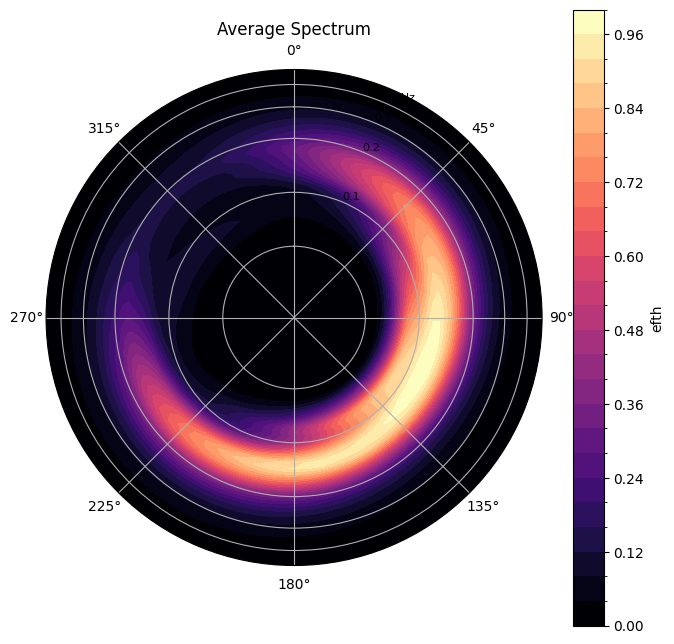

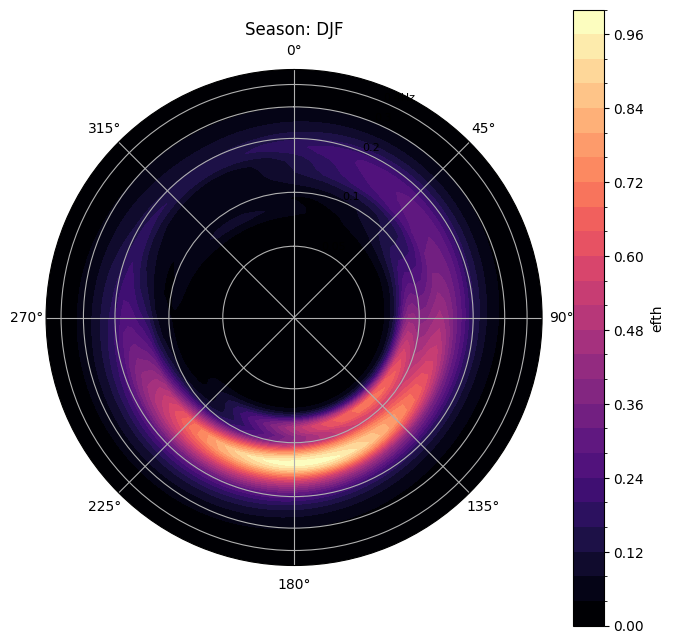

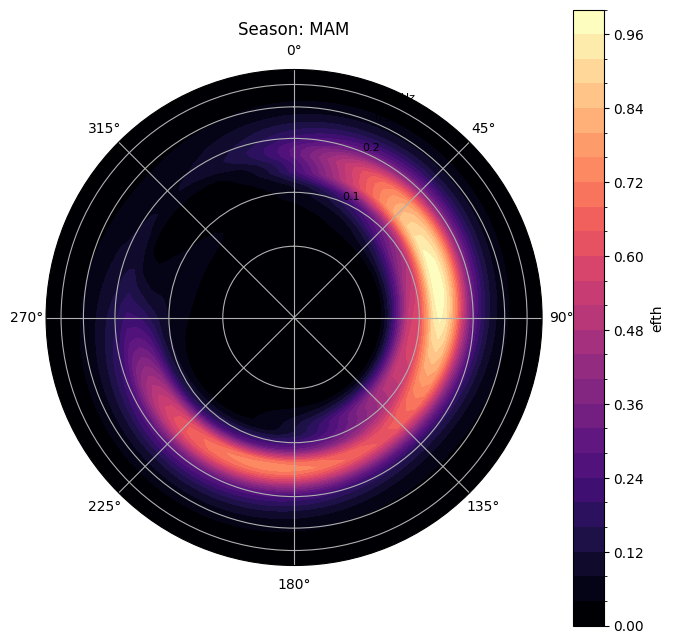

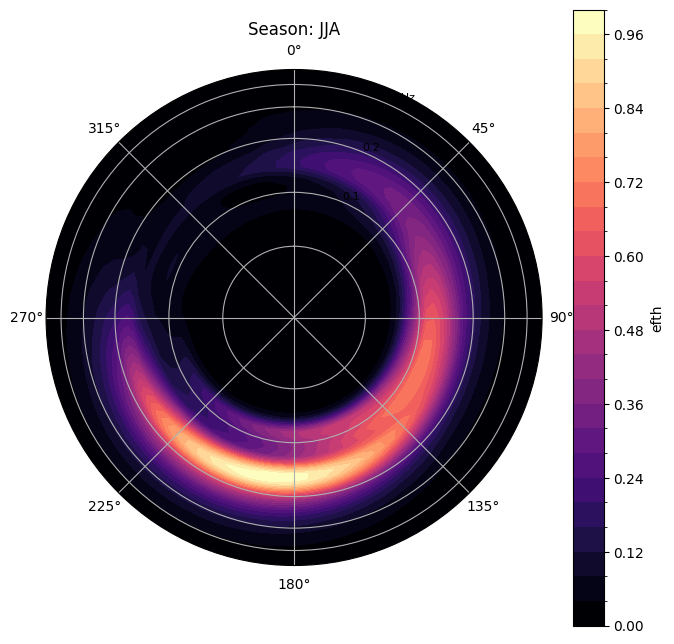

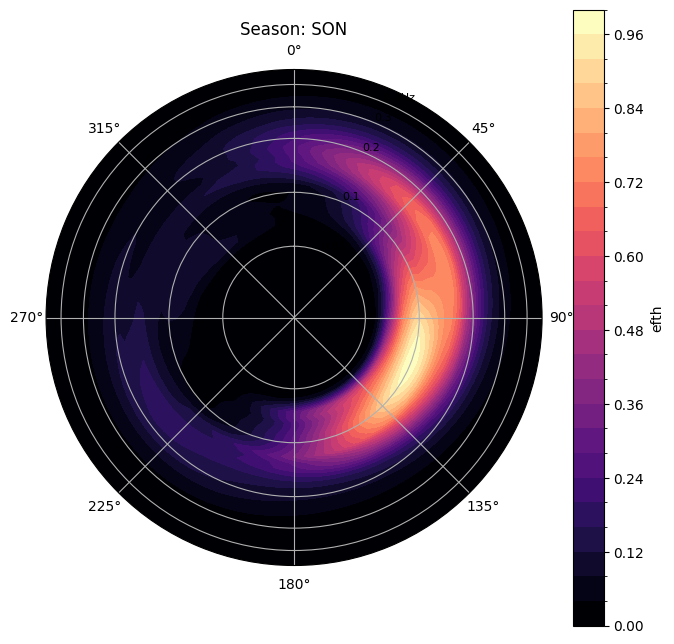

In [ ]:
import os
import xarray as xr
import wavespectra as ws
import matplotlib.pyplot as plt

folder = "buoy_spectra"
files = [f for f in os.listdir(folder) if f.endswith('.nc')]

for fname in files:
    fpath = os.path.join(folder, fname)
    ds = xr.open_dataset(fpath).rename({"direction": "dir", "frequency": "freq"})

    # --- Individual time-averaged spectrum ---
    time_averaged_data = ds.mean(dim='time')
    spec = ws.SpecArray(time_averaged_data.efth)
    fig = plt.figure(figsize=(8, 8))
    spec.plot(kind='contourf', cmap='magma', levels=30)
    plt.title(f"Average Spectrum")
    plt.savefig(f"{fname}_Average.png")
    plt.show()

    # --- Seasonal spectra ---
    if "time" in ds.dims:
        # Group by season and average
        seasonal = ds.efth.groupby('time.season').mean('time')
        seasons = ['DJF', 'MAM', 'JJA', 'SON']
        for season in seasons:
            if season in seasonal.season.values:
                spec_season = ws.SpecArray(seasonal.sel(season=season))
                fig = plt.figure(figsize=(8, 8))
                spec_season.plot(kind='contourf', cmap='magma', levels=30)
                plt.title(f"Season: {season}")
                # plt.savefig(f"{fname}_season_{season}.png")
                plt.show()